# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities? 
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

-----------Part 1----------
(16753, 18)
sale_price                     0
house_square_feet              0
attic_finished_square_feet     0
basement_square_feet           0
attached_garage_square_feet    0
detached_garage_square_feet    0
fireplaces                     0
hvac_description               0
exterior                       0
stories                        0
roof_cover                     0
year_built                     0
bedrooms                       0
bathrooms                      0
waterfront_type                0
view_quality                   0
sale_month                     0
log_price                      0
dtype: int64
-----------Part 1.5----------


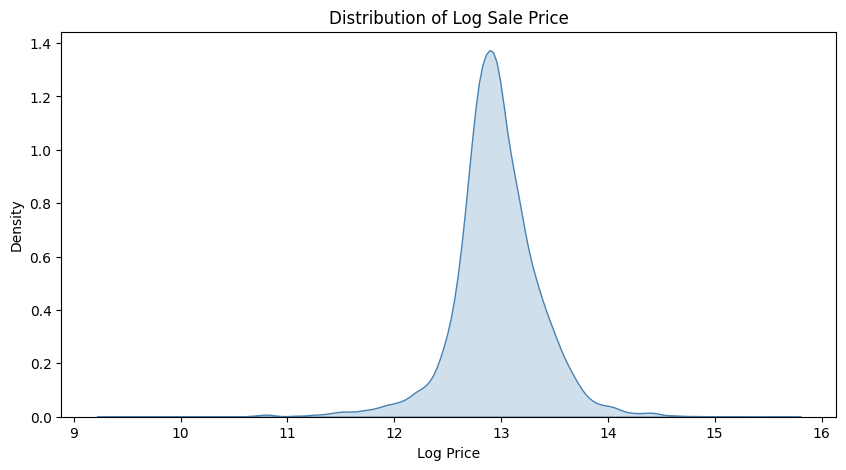

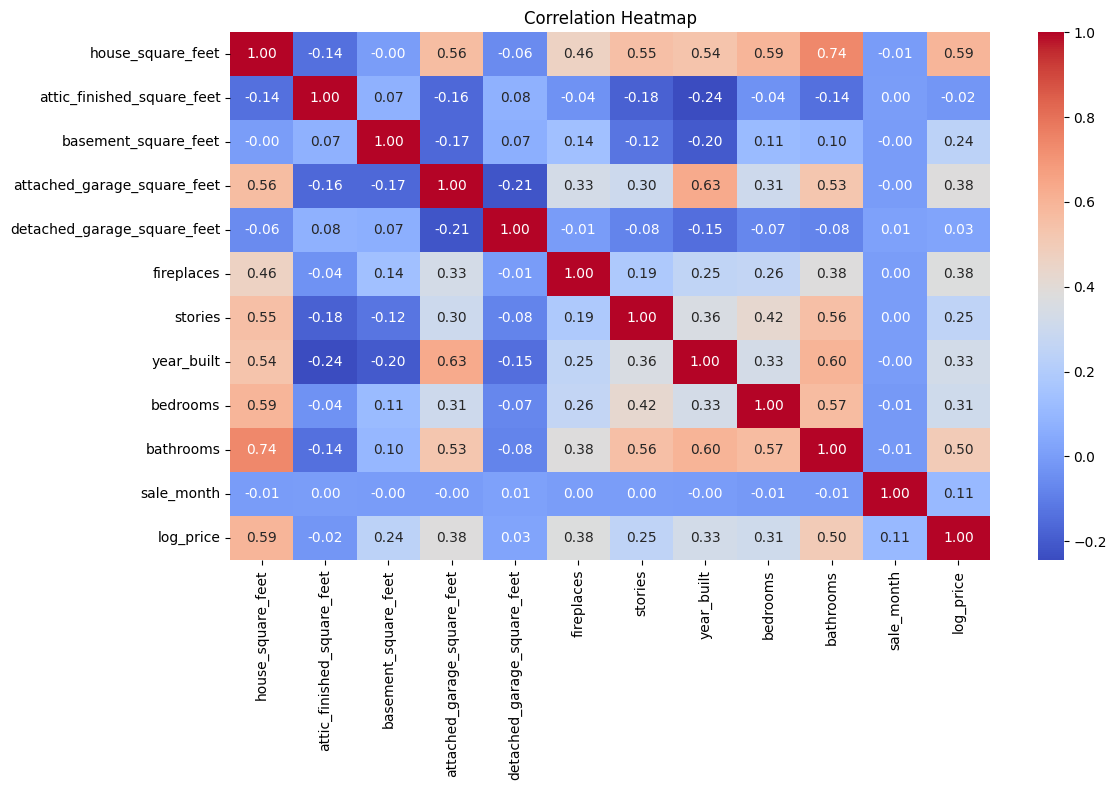

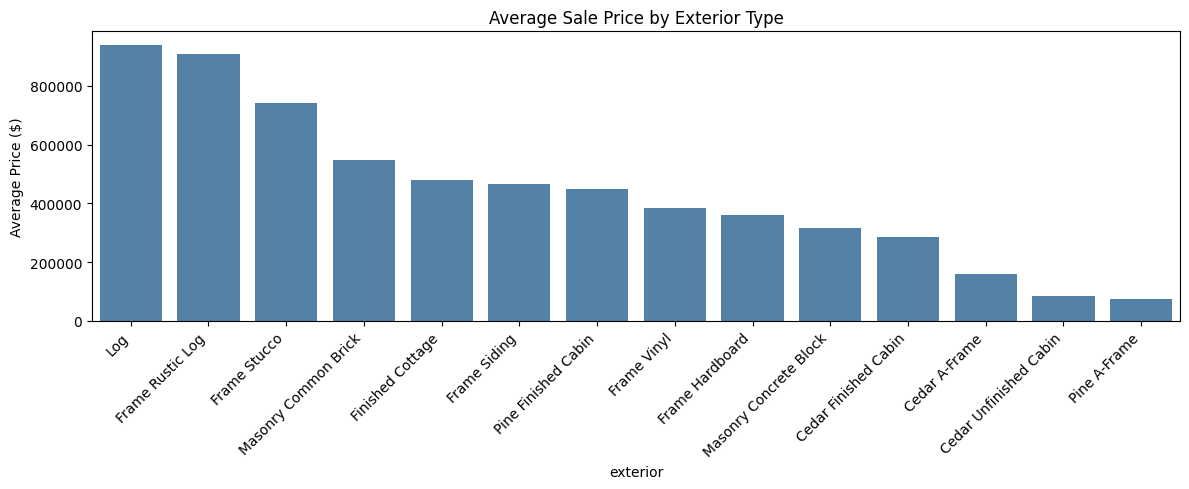


-----------Part 2---------

(16753, 51)
sale_price                                   int64
house_square_feet                            int64
attic_finished_square_feet                   int64
basement_square_feet                         int64
attached_garage_square_feet                  int64
detached_garage_square_feet                  int64
fireplaces                                   int64
stories                                      int64
year_built                                   int64
bedrooms                                     int64
bathrooms                                    int64
sale_month                                   int32
log_price                                  float64
hvac_description_Electric Baseboard           bool
hvac_description_Floor Wall Furnace           bool
hvac_description_Floor/Wall Furnace           bool
hvac_description_Forced Air                   bool
hvac_description_Heat Pump                    bool
hvac_description_Hot Water Baseboard     

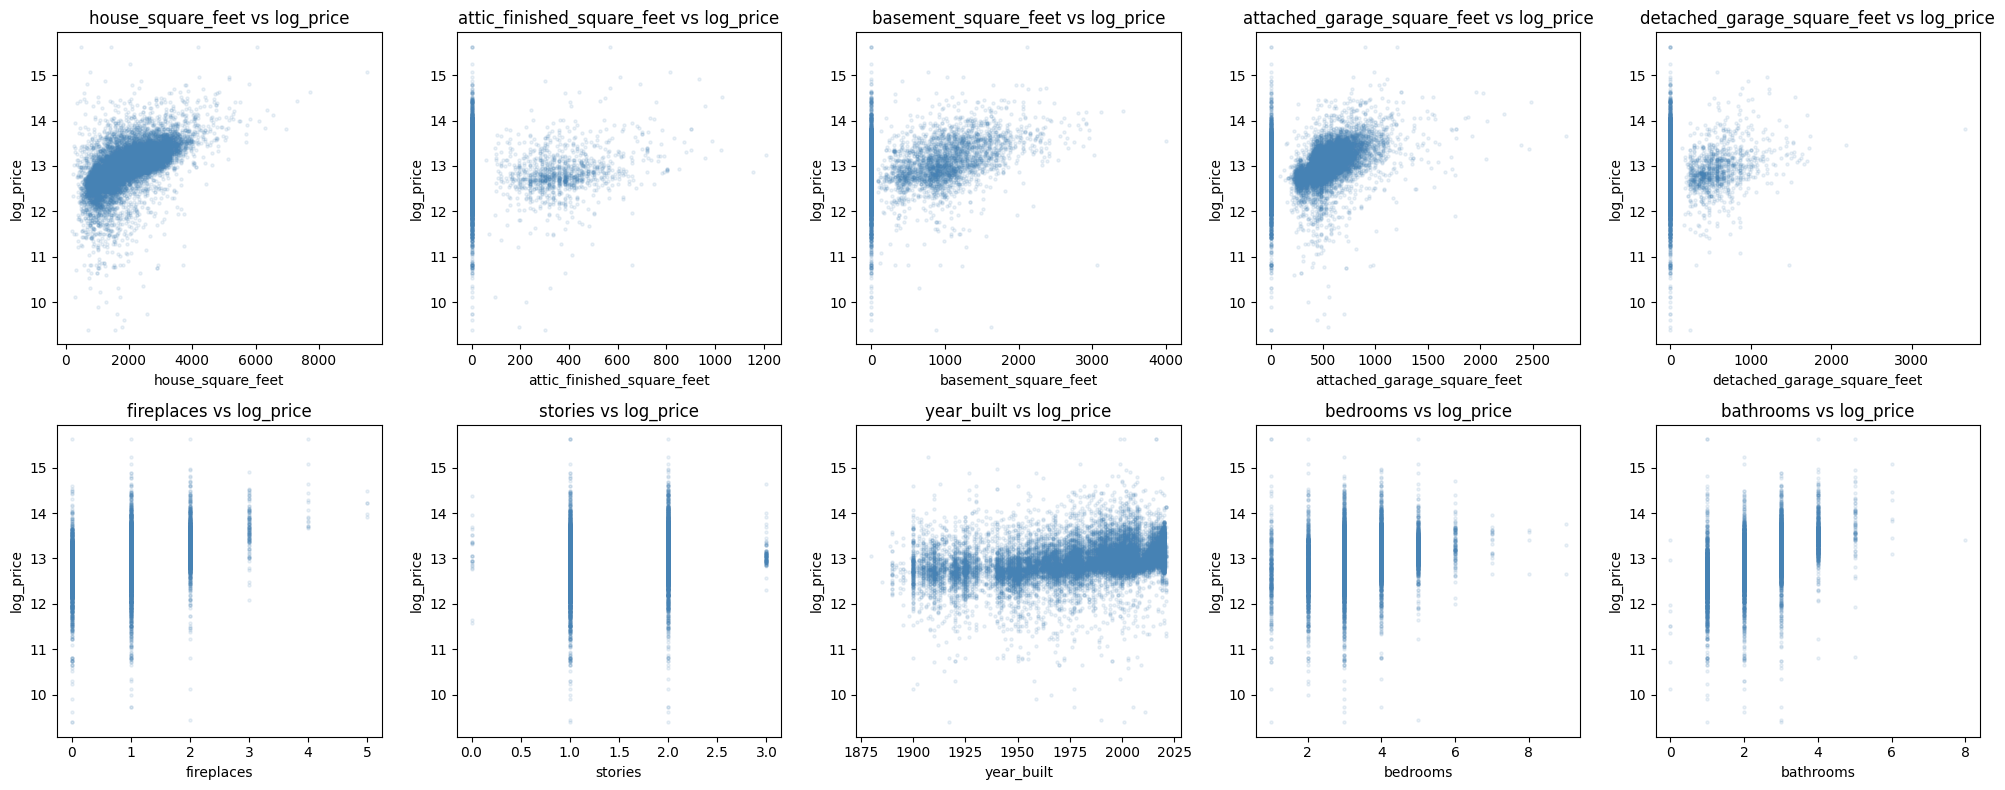

All of them show interesting pattern, but house square feet seems to show a type of log pattern. It has a curve that seems to go up, and then start leveling out as the x values increase, showing non-linear pattern. The other 5 non categorial variables seem to have a slight liner, but it's more of a cluster and a large streak at the start due to zero values. The categorial values seem to have a large clusters due to it being categorial, therefore not much linear relationship can be shown.

-----------Part 6---------

Complex Model Train R2: 0.5219, Test R2: 0.5200
Complex Model Train RMSE: 0.2886, Test RMSE: 0.2924
Compared to the complex model, it does beat it by a little bit on the r squared value, getting an edge of about .01, showing that changing the variables can improve the data relationship, but it's not in a super significant way. Same goes for the error, slight lower but not by a large amount.

-----------Part 7---------

Basically, with the best model that was used, about 52 

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

print("-----------Part 1----------")
df = pd.read_csv("./data/pierce_county_house_sales.csv")
df = df.dropna(subset=['hvac_description', 'exterior', 'interior', 'roof_cover'])

df['waterfront_type'] = df['waterfront_type'].fillna('None')
df['view_quality'] = df['view_quality'].fillna('None')
df = df.drop(columns=['interior', 'utility_sewer'])

df = df[df['sale_price'] > 10000]
df = df[df['house_square_feet'] > 100]
df = df[df['bedrooms'] <= 10]
df = df[df['bedrooms'] >= 1]

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_month'] = df['sale_date'].dt.month
df = df.drop(columns=['sale_date'])

df['log_price'] = np.log(df['sale_price'])

print(df.shape)
print(df.isnull().sum())

print("-----------Part 1.5----------") # Had a little help from Claude setting up the heatmap here.
plt.figure(figsize=(10, 5))
sns.kdeplot(df['log_price'], fill=True, color='steelblue')
plt.title('Distribution of Log Sale Price')
plt.xlabel('Log Price')
plt.show()


plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['sale_price'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
avg_by_exterior = df.groupby('exterior')['sale_price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_exterior.index, y=avg_by_exterior.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Average Sale Price by Exterior Type')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

print("\n"+"-----------Part 2---------" + "\n")
df_encoded = pd.get_dummies(df, columns=['hvac_description', 'exterior', 'roof_cover', 'waterfront_type', 'view_quality'], drop_first=True)
print(df_encoded.shape)
print(df_encoded.dtypes)

print("\n"+"-----------Part 3---------" + "\n")
X = df_encoded.drop(columns=['sale_price', 'log_price'])
y = df_encoded['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

print("\n"+"-----------Part 4---------" + "\n") # Same code as assignment
X_num = df.select_dtypes(include=[np.number]).drop(columns=['sale_price',"log_price"])
y = df['log_price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_num, y, test_size=0.2, random_state=14)
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
train_preds2 = model2.predict(X_train2)
test_preds2 = model2.predict(X_test2)
print(f"Model 1 Train R2: {r2_score(y_train2, train_preds2):.4f}, Test R2: {r2_score(y_test2, test_preds2):.4f}")
print(f"Model 1 Train RMSE: {np.sqrt(mean_squared_error(y_train2, train_preds2)):.4f}, Test RMSE: {np.sqrt(mean_squared_error(y_test2, test_preds2)):.4f}")

df_cat = pd.get_dummies(df.select_dtypes(include=['object', 'string']), drop_first=True)
y = df['log_price']
X_train3, X_test3, y_train3, y_test3 = train_test_split(df_cat, y, test_size=0.2, random_state=14)
model3 = LinearRegression()
model3.fit(X_train3, y_train3)
train_preds3 = model3.predict(X_train3)
test_preds3 = model3.predict(X_test3)
print(f"Model 2 Train R2: {r2_score(y_train3, train_preds3):.4f}, Test R2: {r2_score(y_test3, test_preds3):.4f}")
print(f"Model 2 Train RMSE: {np.sqrt(mean_squared_error(y_train3, train_preds3)):.4f}, Test RMSE: {np.sqrt(mean_squared_error(y_test3, test_preds3)):.4f}")

X_joint = pd.concat([X_num, df_cat], axis=1)
X_train_j, X_test_j, y_trainj, y_testj = train_test_split(X_joint, y, test_size=0.2, random_state=14)
model4 = LinearRegression()
model4.fit(X_train_j, y_trainj)
test_preds4 = model4.predict(X_test_j)
train_preds4 = model4.predict(X_train_j)
print(f"Model 3 Train R2: {r2_score(y_trainj, train_preds4):.4f}, Test R2: {r2_score(y_testj, test_preds4):.4f}")
print(f"Model 3 Train RMSE: {np.sqrt(mean_squared_error(y_trainj, train_preds4)):.4f}, Test RMSE: {np.sqrt(mean_squared_error(y_testj, test_preds4)):.4f}")

print("Model 3, the combined model, seems to have performed the best, as it's R2 value is higher compared to the other 2 models. The 2nd model, which did not include numerical values, did the worse at a very low R2 value of 0.27. Overall the models did not overfit or underfit in a severe way, but the combined model definitely outdid the others. ")

print("\n"+"-----------Part 5---------" + "\n") # Had Gemini Help me here as I didn't know how to set up the loop for the plots.
num_cats = df.select_dtypes(include=[np.number]).drop(columns=['sale_price',"log_price"])
num_cats = num_cats.drop(columns=['sale_month'])
print(num_cats.columns.tolist())
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cats):
    axes[i].scatter(df[col], df['log_price'], alpha=0.1, color='steelblue', s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_price')
    axes[i].set_title(f'{col} vs log_price')
plt.tight_layout()
plt.show()
print("All of them show interesting pattern, but house square feet seems to show a type of log pattern. It has a curve that seems to go up, and then start leveling out as the x values increase, showing non-linear pattern. The other 5 non categorial variables seem to have a slight liner, but it's more of a cluster and a large streak at the start due to zero values. The categorial values seem to have a large clusters due to it being categorial, therefore not much linear relationship can be shown.")

print("\n"+"-----------Part 6---------" + "\n")
df_encoded['log_sqft'] = np.log(df_encoded['house_square_feet'])
df_encoded['year_built_sq'] = df_encoded['year_built'] ** 2
df_encoded['bath_bed_interaction'] = df_encoded['bathrooms'] * df_encoded['bedrooms']
X_complex = df_encoded.drop(columns=['sale_price', 'log_price'])
y = df_encoded['log_price']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_complex, y, test_size=0.2, random_state=14)
model_complex = LinearRegression()
model_complex.fit(X_train_c, y_train_c)
train_preds_c = model_complex.predict(X_train_c)
test_preds_c = model_complex.predict(X_test_c)

print(f"Complex Model Train R2: {r2_score(y_train_c, train_preds_c):.4f}, Test R2: {r2_score(y_test_c, test_preds_c):.4f}")
print(f"Complex Model Train RMSE: {np.sqrt(mean_squared_error(y_train_c, train_preds_c)):.4f}, Test RMSE: {np.sqrt(mean_squared_error(y_test_c, test_preds_c)):.4f}")
print("Compared to the complex model, it does beat it by a little bit on the r squared value, getting an edge of about .01, showing that changing the variables can improve the data relationship, but it's not in a super significant way. Same goes for the error, slight lower but not by a large amount.")

print("\n"+"-----------Part 7---------" + "\n")
print("Basically, with the best model that was used, about 52 percent of a house's features that was given by the csv file can explain the variation of prices on different homes, shown by the R2 value of 0.52. Categorial variables didn't have as big as an impact, only around 27% percent of variation on it's own, but numerical variables on their own got a higher variation, around 45%. When combining them, and eventually changing some of the data, it increased this to the 52 percent now listed. This complex model has a squared year built, log square footage, and combined bedrooms and bathrooms into one. None of the models showed overfitting, due to the training and testing data being very identical, thought a non-linear model would help to prevent some possible underfitting, as shown by the graphical designs below. ")

print("\n"+"-----------Part 8---------" + "\n") # Had Gemini help me set this up
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train_c)
lasso_preds = lasso.predict(X_test_scaled)
print(f"Lasso Test R2: {r2_score(y_test_c, lasso_preds):.4f}")
print(f"Lasso Test RMSE: {np.sqrt(mean_squared_error(y_test_c, lasso_preds)):.4f}")
coef_df = pd.DataFrame({'Feature': X_complex.columns, 'Coefficient': lasso.coef_})
print(coef_df[coef_df['Coefficient'] != 0].sort_values('Coefficient', ascending=False))
